In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.shape

(891, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Fare"].fillna(df["Fare"].median(), inplace=True)

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


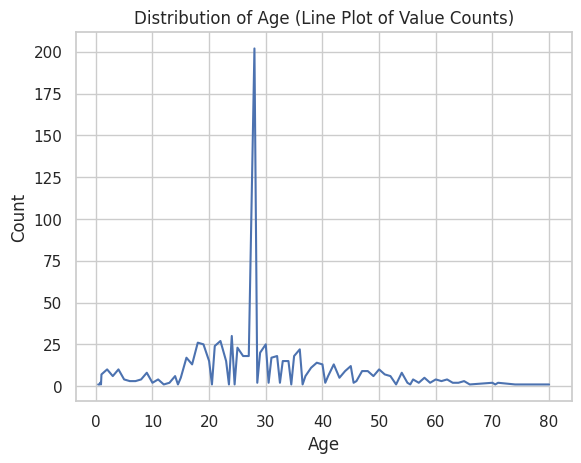

In [10]:
age_counts = df["Age"].value_counts().sort_index()
plt.plot(age_counts.index, age_counts.values)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age (Line Plot of Value Counts)")
plt.show()

In [11]:
df.drop(["Cabin", "Name", "Ticket","PassengerId"], axis=1, inplace=True)

In [12]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


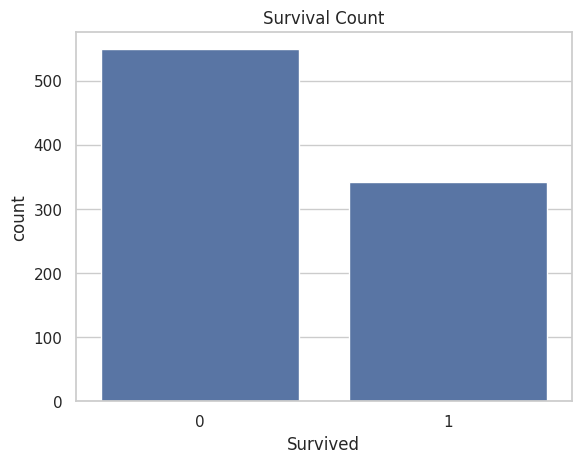

In [13]:
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

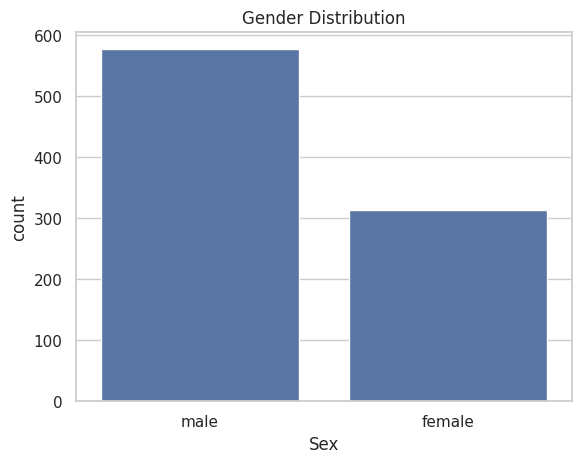

In [14]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

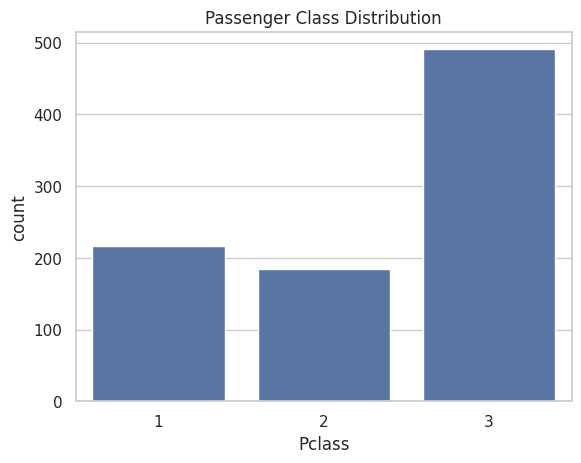

In [15]:
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class Distribution")
plt.show()

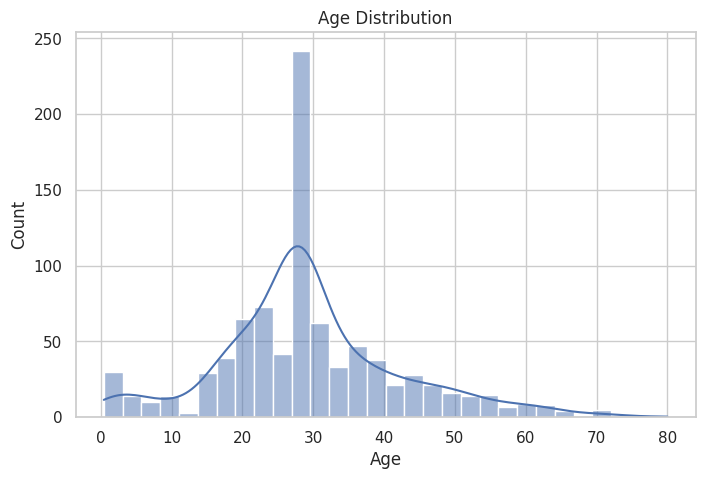

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

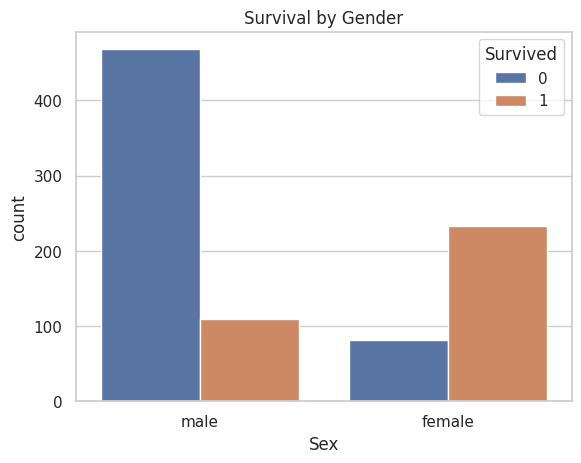

In [17]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title("Survival by Gender")
plt.show()

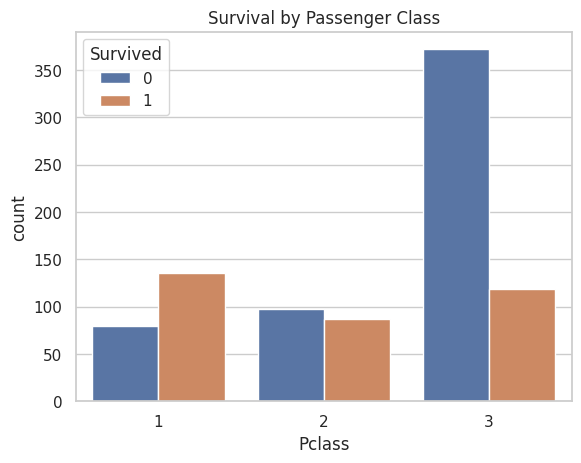

In [18]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

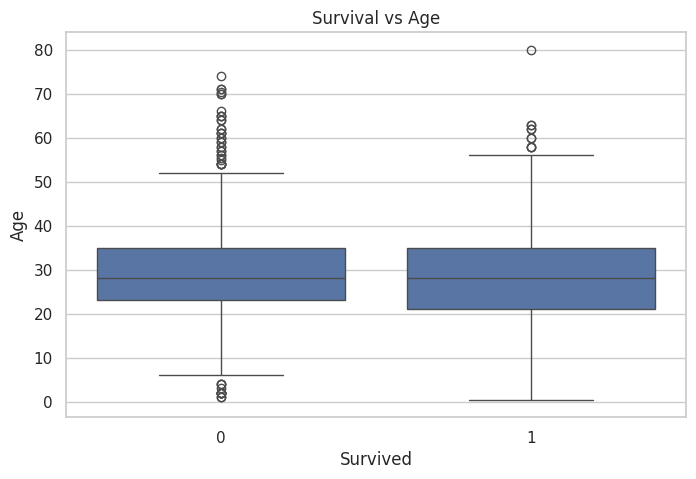

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title("Survival vs Age")
plt.show()

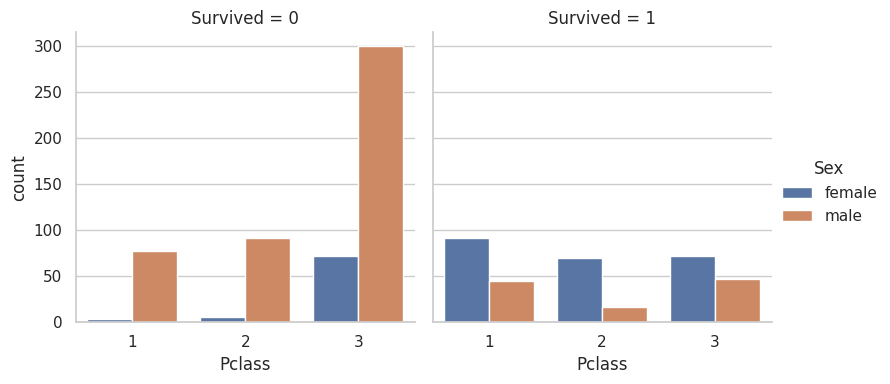

In [20]:
sns.catplot(x='Pclass', hue='Sex', col='Survived',
            data=df, kind='count', height=4)
plt.show()

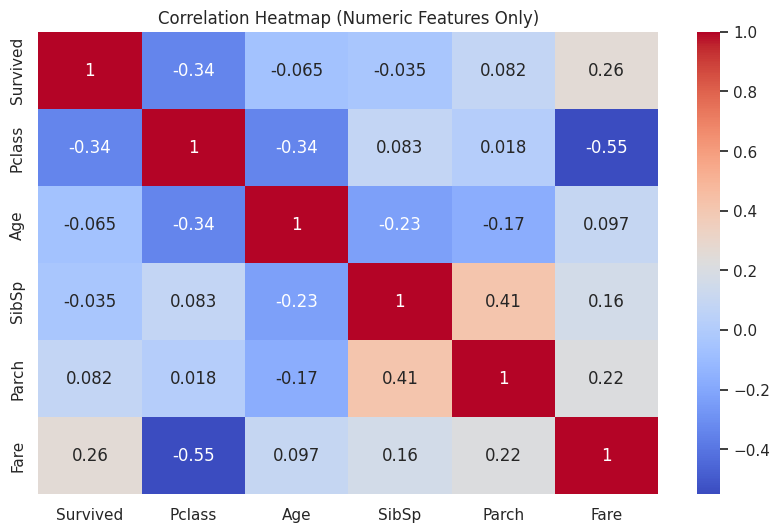

In [21]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()

In [22]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [23]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )


In [24]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)


In [25]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=1000)
# model.fit(X_train, y_train)


In [26]:
# y_pred = model.predict(X_test)


In [27]:
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))


In [28]:
# from sklearn.model_selection import cross_val_score

# scores = cross_val_score(
#     model, X, y, cv=5, scoring="accuracy"
# )

# print(scores)
# print("Mean CV Accuracy:", scores.mean())


In [29]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

X = df.drop("Survived", axis=1)
y = df["Survived"]
X

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

pipe.fit(X_train, y_train)


y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
 [[90 15]
 [19 55]]


In [31]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("risk_model.pkl")
columns = joblib.load("model_columns.pkl")

st.title("Customer Risk Prediction")

# Example inputs
loan_amount = st.number_input("Loan Amount")
emi = st.number_input("EMI Amount")
delay = st.number_input("Payment Delay Days")
score = st.number_input("Customer Score")

if st.button("Predict Risk"):
    input_df = pd.DataFrame([[loan_amount, emi, delay, score]], columns=columns[:4])
    prediction = model.predict(input_df)
    st.success(f"Predicted Risk Level: {prediction[0]}")


ModuleNotFoundError: No module named 'streamlit'